In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats


sns.set_theme()
plt.rcParams["figure.figsize"] = (9, 6)


1. This exercise is based on the midge data of Table 1.1.

In [37]:
df = pd.read_csv("data/table1-1.csv")
df.head()

,Species,Antenna Length,Wing Length
0,Af,1.38,1.64
1,Af,1.40,1.70
2,Af,1.24,1.72
3,Af,1.36,1.74
4,Af,1.38,1.82


(a) With X =antenna length, Y = wing length, compute the value of Z = X/Y for all 16midges, and verify that the variable Z separates the two groups completely.

In [38]:
df["Z"] = df["Antenna Length"] / df["Wing Length"]
df["Z>0.7"] = df["Z"] > 0.7
df

,Species,Antenna Length,Wing Length,Z,Z>0.7
0,Af,1.38,1.64,0.841463,True
1,Af,1.40,1.70,0.823529,True
2,Af,1.24,1.72,0.720930,True
3,Af,1.36,1.74,0.781609,True
4,Af,1.38,1.82,0.758242,True
5,Af,1.48,1.82,0.813187,True
6,Af,1.54,1.82,0.846154,True
7,Af,1.38,1.90,0.726316,True
8,Af,1.56,2.08,0.750000,True
9,Apf,1.14,1.78,0.640449,False


(b) Consider the classification rule based on the two areas of classification

$$D_1 = \{(x, y) : x/y > 0.7\} \quad (\text{for } Af)$$

and

$$D_2 = \{(x, y) : x/y < 0.7\} \quad (\text{for } Apf).$$

Graph the boundary between the two areas of classification in a scatterplot of $x$ vs. $y$ (like Figure 1.1), and compare it to Figure 1.2.

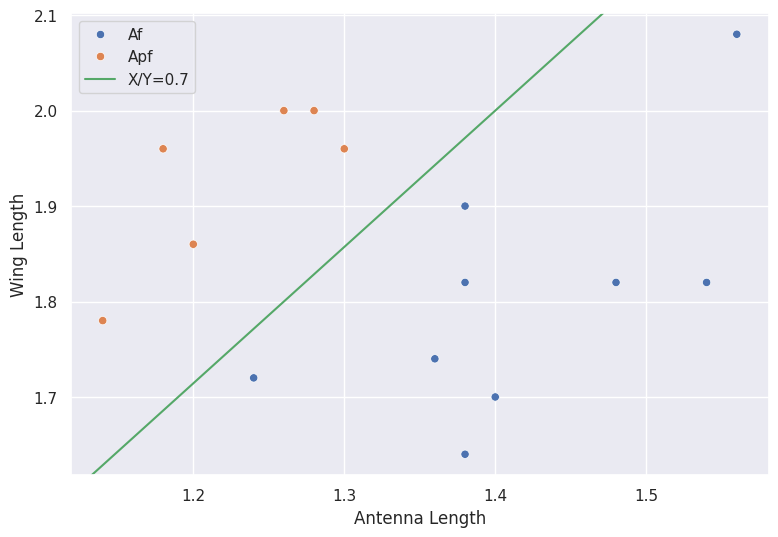

In [39]:
sns.scatterplot(df, x="Antenna Length", y = "Wing Length",hue="Species")
plt.autoscale(False)
plt.axline((0,0),slope=10/7,c="g",label="X/Y=0.7")
plt.legend()
plt.show()

(b) Compute the coordinates u and v of the data of all 16 midges in the rotated coordinate system.

$$
\begin{aligned}
&u =\frac{x-y}{\sqrt2},\quad v = \frac{x+y}{\sqrt2}\\
\iff & x=\frac{\sqrt2}{2}(u+v),\quad y = \frac{\sqrt2}{2}(v-u)
\end{aligned}
$$

$$
\frac{x}{y}=0.7\implies \frac{\frac{\sqrt2}{2}(u+v)}{\frac{\sqrt2}{2}(v-u)}=\frac{u+v}{v-u}=0.7\implies \frac{v}{u}=-\frac{17}{3}
$$

In [40]:
df["U"] = (df["Antenna Length"] - df["Wing Length"]) / 2**0.5
df["V"] = (df["Antenna Length"] + df["Wing Length"]) / 2**0.5
df

,Species,Antenna Length,Wing Length,Z,Z>0.7,U,V
0,Af,1.38,1.64,0.841463,True,-0.183848,2.135462
1,Af,1.40,1.70,0.823529,True,-0.212132,2.192031
2,Af,1.24,1.72,0.720930,True,-0.339411,2.093036
3,Af,1.36,1.74,0.781609,True,-0.268701,2.192031
4,Af,1.38,1.82,0.758242,True,-0.311127,2.262742
5,Af,1.48,1.82,0.813187,True,-0.240416,2.333452
6,Af,1.54,1.82,0.846154,True,-0.197990,2.375879
7,Af,1.38,1.90,0.726316,True,-0.367696,2.319310
8,Af,1.56,2.08,0.750000,True,-0.367696,2.573869
9,Apf,1.14,1.78,0.640449,False,-0.452548,2.064752


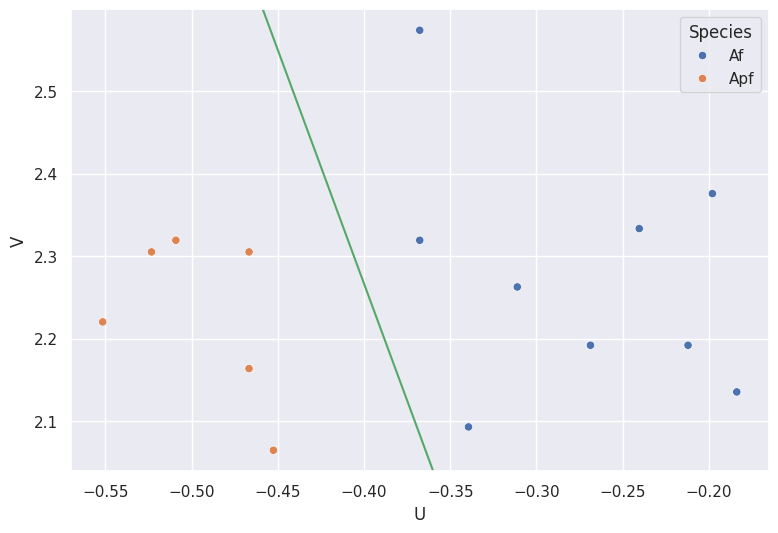

In [ ]:
sns.scatterplot(df, x="U", y = "V",hue="Species")
plt.autoscale(False)
plt.axline((0,0),slope=-17/3,c="g",label="X/Y=0.7")
plt.show()

(c) Can you relate the classification rule given in Example 1.1 to the (u, v)-coordinate system? In your plot of U vs V, what would the classification regions C 1 and C2 look like?

$$
y-x=0.58 \implies \frac{\sqrt2}{2}(v-u) - \frac{\sqrt2}{2}(u+v) = -\sqrt2 u=0.58 \implies u = -\frac{0.58}{\sqrt 2}
$$

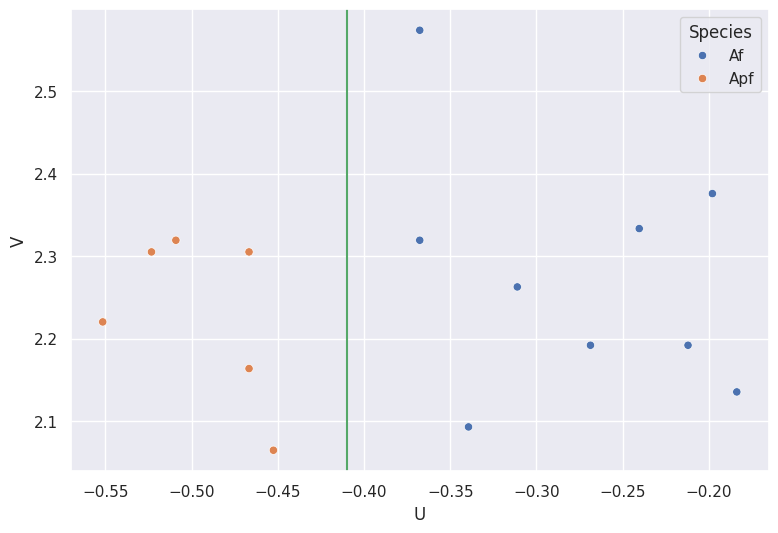

In [42]:
sns.scatterplot(df, x="U", y="V", hue="Species")
plt.axvline(-0.58 / 2**0.5, c="g")
plt.show()

3. This exercise is based on the head dimension data of Example 1.2.

In [43]:
df = pd.read_csv("data/table1-2.csv")
df.head()

,MFB,BAM,TFH,LGAN,LTN,LTG
0,113.2,111.7,119.6,53.9,127.4,143.6
1,117.6,117.3,121.2,47.7,124.7,143.9
2,112.3,124.7,131.6,56.7,123.4,149.3
3,116.2,110.5,114.2,57.9,121.6,140.9
4,112.9,111.3,114.3,51.5,119.9,133.5


(a) Get started with your favorite software by computing means and standard deviations for all six variables, as well as all 15 pairwise correlations between
variables.

In [44]:
means = df.mean()
stds = df.std(ddof=1)
corr_matrix = df.corr()

print(f"Means:\n{means}")
print(f"\nStandard Deviations:\n{stds}")
print(f"\nCorrelation Matrix:\n{corr_matrix}")

Means:
MFB     114.7245
BAM     115.9140
TFH     123.0550
LGAN     57.9885
LTN     122.2340
LTG     138.8335
dtype: float64

Standard Deviations:
MFB     5.186632
BAM     5.220361
TFH     5.935489
LGAN    4.224375
LTN     3.920484
LTG     5.642421
dtype: float64

Correlation Matrix:
           MFB       BAM       TFH      LGAN       LTN       LTG
MFB   1.000000  0.466200  0.174869  0.133788  0.402115  0.413711
BAM   0.466200  1.000000  0.092963  0.093301  0.348157  0.388425
TFH   0.174869  0.092963  1.000000  0.413550  0.259023  0.238052
LGAN  0.133788  0.093301  0.413550  1.000000  0.176275  0.209501
LTN   0.402115  0.348157  0.259023  0.176275  1.000000  0.656447
LTG   0.413711  0.388425  0.238052  0.209501  0.656447  1.000000


(b) Now consider only the two variables X = LTG and Y = LTN. Rotate the (x, y)-coordinate system by 30 degrees, i.e., compute 
$$ u = cx +sy $$
and
$$ v = -sx + cy,$$
where $c = \cos(\pi/6)\approx 0.866, s = \sin(\pi/6)=0.5$, for all 200 observations.

In [45]:
rot = np.pi / 6
c, s = np.cos(rot), np.sin(rot)
df["u"] = c*df["LTG"] + s*df["LTN"]
df["v"] = -s*df["LTG"] + c*df["LTN"]
df.head()

,MFB,BAM,TFH,LGAN,LTN,LTG,u,v
0,113.2,111.7,119.6,53.9,127.4,143.6,188.061248,38.531636
1,117.6,117.3,121.2,47.7,124.7,143.9,186.971056,36.043368
2,112.3,124.7,131.6,56.7,123.4,149.3,190.997593,32.217535
3,116.2,110.5,114.2,57.9,121.6,140.9,182.822979,34.858689
4,112.9,111.3,114.3,51.5,119.9,133.5,175.564391,37.086446


In [46]:
means = df[["u","v"]].mean()
stds = df[["u","v"]].std(ddof=1)
corr_matrix = df[["u","v"]].corr()

print(f"Means:\n{means}")
print(f"\nStandard Deviations:\n{stds}")
print(f"\nCorrelation Matrix:\n{corr_matrix}")

Means:
u    181.350338
v     36.440999
dtype: float64

Standard Deviations:
u    6.347915
v    2.628895
dtype: float64

Correlation Matrix:
         u        v
u  1.00000  0.00781
v  0.00781  1.00000


In [47]:
df[["u", "v"]].var(ddof=1).sum() - df[["LTG", "LTN"]].var(ddof=1).sum()

np.float64(0.0)

This exercise is based on the well-known turtle carapace data of Jolicoeur and Mosimann (1960). The data are given in Table 1.4. There are three variables,
$$ L = \text{carapace length,} $$
$$ W = \text{carapace width,} $$
and
$$
H = \text{carapace height,}
$$
all measured in mm, of 24 male and 24 female painted turtles (Chrysemys picta marginata) .

In [48]:
df = pd.read_csv("data/table1-4.csv")
df.head()

,Gender,Length,Width,Height
0,M,93,74,37
1,M,94,78,35
2,M,96,80,35
3,M,101,84,39
4,M,102,85,38


(a) For both groups individually, compute means and standard deviations for all three variables, as well as all three correlations between pairs of variables. Based on these descriptive statistics, how could you describe the differences between carapaces of male and female turtles?

In [49]:
male = df[df["Gender"] == "M"][["Length", "Width", "Height"]]
means = male.mean()
stds = male.std(ddof=1)
corr_matrix = male.corr()
print("Males:")
print(f"Means:\n{means}")
print(f"\nStandard Deviations:\n{stds}")
print(f"\nCorrelation Matrix:\n{corr_matrix}")

female = df[df["Gender"] == "F"][["Length", "Width", "Height"]]
means = female.mean()
stds = female.std(ddof=1)
corr_matrix = female.corr()

print("\n==================\n")
print("Feales:")
print(f"Means:\n{means}")
print(f"\nStandard Deviations:\n{stds}")
print(f"\nCorrelation Matrix:\n{corr_matrix}")

Males:
Means:
Length    113.375000
Width      88.291667
Height     40.708333
dtype: float64

Standard Deviations:
Length    11.779911
Width      7.074013
Height     3.355452
dtype: float64

Correlation Matrix:
          Length     Width    Height
Length  1.000000  0.949785  0.945558
Width   0.949785  1.000000  0.912265
Height  0.945558  0.912265  1.000000


Feales:
Means:
Length    136.000000
Width     102.583333
Height     51.958333
dtype: float64

Standard Deviations:
Length    21.245971
Width     13.104651
Height     8.163967
dtype: float64

Correlation Matrix:
          Length     Width    Height
Length  1.000000  0.973971  0.972582
Width   0.973971  1.000000  0.965419
Height  0.972582  0.965419  1.000000


雌性龜殼在各項數據的平均都比雄性高

(b) For female turtles only, plot L vs, W .

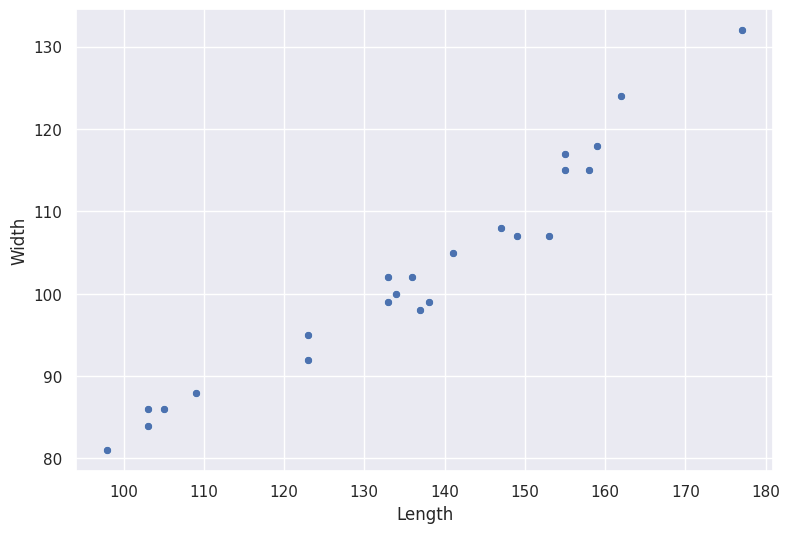

In [50]:
sns.scatterplot(female,x="Length",y="Width")
plt.show()

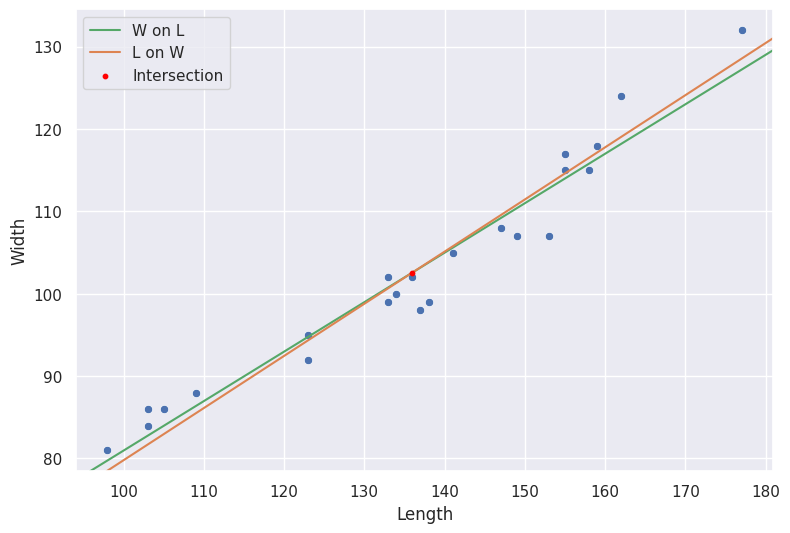

In [84]:
slope1, intercept1, _, _, _ = stats.linregress(female["Length"], female["Width"])
slope2, intercept2, _, _, _ = stats.linregress(female["Width"], female["Length"])
L_star = (-intercept1 - intercept2 / slope2) / (slope1 - 1 / slope2)
W_star = slope1 * L_star + intercept1

sns.scatterplot(data=female, x="Length", y="Width")
plt.axline((L_star, W_star), slope=slope1, color="C2", label="W on L")
plt.axline((L_star, W_star), slope=1 / slope2, color="C1", label="L on W")
plt.scatter(L_star, W_star, color="red", s=10, zorder=5, label="Intersection")
plt.legend()
plt.show()

(d) Which of the two lines in part (c) would you prefer for the purpose of approximating the two-dimensional scatterplot by a straight line? Recall that the two regression lines result from least squares approximations where distance from the line is measured either horizontally or vertically. Can you think of a third way to measure distance from the line that would lead to a "compromise" between the two regression lines? How would you tackle the analogous problem with a three-dimensional scatterplot, i.e., if you want to approximate three-dimensional data by a single straight line? (Note: At this point, no "perfect" solution is expected. The purpose of part (d) is to get you started thinking about problems that we will solve later in Chapter 8).

如果需要使用 L 預測 W,那麼應該使用 W on L 的線，反之則選擇 L on W。因爲中回歸本質是最小化點到線沿 y/x 軸方向的距離，一種這種的方案可以是最小化所有點到線的垂直距離。在三位中仍可以最小化點到線垂直距離。

(e) Construct a scatterplot of L vs. H for all 48 turtles, using different symbols for males and females . Find a rule (by simply drawing a straight boundary line in the scatterplot) that would allow you to classify a turtle as male or female, based on the measurements of Land H. How well would you expect your rule to perform? Do you think that classification based on both variables would be better than classification based on either L or H alone? (Note: Again, you are not expected to give a perfect solution. This type of problem will be discussed extensively in Chapters 5 and 7).

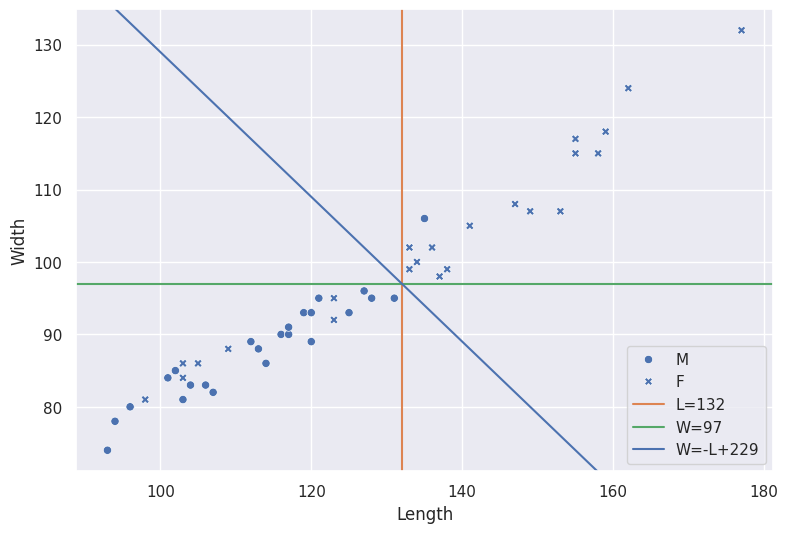

In [86]:
sns.scatterplot(df, x="Length", y="Width", style="Gender")
plt.axvline(132, c="C1", label="L=132")
plt.axhline(97, c="C2", label="W=97")
plt.axline((132, 97), slope=-1,label="W=-L+229")
plt.legend()
plt.show()

在這筆數據下，結合兩種數據並沒有比單個數據更好

5. This exercise is based on the water pipit data of Example 1.3.

In [87]:
df = pd.read_csv("data/table1-3.csv")
df.head()

,Wing Length,Frequency
0,82,5
1,83,3
2,84,12
3,85,36
4,86,55


(a) Divide the data into two groups according to wing length $\le 89$, and wing length $\ge 90$. Separately, for each group, compute the mean and the standard deviation of wing length .

In [89]:
g1 = df[df["Wing Length"] <= 89]
means = g1.mean()
stds = g1.std(ddof=1)
print("Wing Length <= 89:")
print(f"Means:\n{means}")
print(f"\nStandard Deviations:\n{stds}")

g2 = df[df["Wing Length"] >= 90]
means = g2.mean()
stds = g2.std(ddof=1)

print("\n==================\n")
print("Wing Length >= 90:")
print(f"Means:\n{means}")
print(f"\nStandard Deviations:\n{stds}")

Wing Length <= 89:
Means:
Wing Length    85.50
Frequency      23.75
dtype: float64

Standard Deviations:
Wing Length     2.449490
Frequency      19.352002
dtype: float64


Wing Length >= 90:
Means:
Wing Length    94.000000
Frequency      21.222222
dtype: float64

Standard Deviations:
Wing Length     2.738613
Frequency      21.064056
dtype: float64


(b) In part (a), one might argue that most birds in the first group are female, and most birds in the second group are male. Therefore, the means and variances computed in (a) should be valid estimates of the means and variances of wing length of female and male birds of the species Anthus spinoletta. Can you think of a reason why this argument is flawed? (Hint : Think of a situation where the distributions of the two groups overlap more than in this particular example.)

可能存在翅膀長度小於 90 的雄性和長度大於 89 的雌性。如果直接使用 (a) 中結果會導致高估雄性的平均，而低估雌性的平均，對於兩者的方差也都會被低估。